<a href="https://colab.research.google.com/github/Allahbachayo786/abm.demo/blob/main/fifa2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ FIFA World Data Analysis & Prediction

## 📌 Project Overview
This project analyzes FIFA World Cup 2026 player data.
**Dataset**: 54,600 rows, 75 columns

### 🎯 Objectives
- Explore and clean FIFA player data
- Perform exploratory data analysis with visualizations
- Build ML models: Random Forest + Neural Network  
- Compare model performance

### 🛠️ Technologies Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow


1. Import Libraries & Load **Dataset**

In [ ]:
import pandas as pd
import numpy as np

# Load FIFA World Cup player performance dataset
df = pd.read_csv(
    "/content/drive/MyDrive/fifa_world_cup_2026_player_performance.csv"
)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()
df.info()

Shape: (54600, 75)

Columns: ['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rati

2. Check Dataset **Information**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Number of rows: 54600
Number of columns: 75

Column names:
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations',

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


3. Remove Empty Rows and **Duplicates**

In [ ]:
# Drop completely empty rows
df = df.dropna(how="all")

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing empty rows and duplicates:", df.shape)

Shape after removing empty rows and duplicates: (54600, 75)


4. Check Missing **Values**

In [ ]:
# See missing values
print(df.isnull().sum())

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64


**5. Fill Missing Numerical Values**



In [ ]:
# Fill numeric columns with median
num_cols = [
    "age",
    "height_cm",
    "weight_kg",
    "market_value_eur"
]

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

6. Fill Missing Text Values

In [ ]:
# Fill text columns with "Unknown"
text_cols = [
    "club_name",
    "preferred_foot"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

**7. Standardize Text Columns**



In [ ]:
# Standardize text columns

df["position"] = df["position"].str.title()
df["preferred_foot"] = df["preferred_foot"].str.title()
df["nationality"] = df["nationality"].str.title()
df["team"] = df["team"].str.title()

8. Fix Position Abbreviations

In [ ]:
# Fix position abbreviations if any

position_map = {
    "Mid": "Midfielder",
    "Def": "Defender",
    "Fwd": "Forward",
    "GK": "Goalkeeper"
}

df["position"] = df["position"].replace(position_map)

9. Calculate BMI

In [ ]:
# BMI

df["bmi"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)

10. Create Age Groups

In [ ]:
# Age groups

bins = [0, 21, 28, 50]
labels = ["U21", "21-28", "29+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

**11. Convert Market Value into Millions**



In [ ]:
# Market value in millions

df["market_val_"] = df["market_value_eur"] / 1000000

12. Extract Year and Month from Match **Date**

In [ ]:
# Convert match_date to datetime

df["match_date"] = pd.to_datetime(
    df["match_date"],
    errors="coerce"
)

# Extract year
df["match_year"] = df["match_date"].dt.year

# Extract month
df["match_month"] = df["match_date"].dt.month

13. Final Data Cleaning Check

In [ ]:
# Final checks

print(
    "Missing values after cleaning:\n",
    df.isnull().sum()
)

print(
    "\nDuplicates:",
    df.duplicated().sum()
)

print("\nDescriptive statistics:")
display(df.describe())

Missing values after cleaning:
 player_id      0
player_name    0
age            0
nationality    0
team           0
              ..
bmi            0
age_group      0
market_val_    0
match_year     0
match_month    0
Length: 80, dtype: int64

Duplicates: 0

Descriptive statistics:


,age,jersey_number,height_cm,weight_kg,market_value_eur,match_date,goals_team,goals_opponent,minutes_played,goals,...,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,bmi,market_val_,match_year,match_month
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.0,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,2026-07-06 19:55:53.142857216,1.330476,1.330476,36.199817,0.055385,...,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046,22.987413,20.084452,2026.0,6.623810
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,2026-06-11 00:00:00,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.522408,0.528822,2026.0,6.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,2026-06-24 00:00:00,0.000000,0.000000,0.000000,0.000000,...,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000,22.096808,4.444778,2026.0,6.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,2026-07-07 00:00:00,1.000000,1.000000,24.000000,0.000000,...,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000,22.944089,10.271107,2026.0,7.000000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2026-07-20 00:00:00,2.000000,2.000000,75.000000,0.000000,...,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000,23.766410,23.420128,2026.0,7.000000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,2026-07-31 00:00:00,7.000000,7.000000,90.000000,4.000000,...,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000,28.027682,200.000000,2026.0,7.000000
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,NaN,1.147814,1.147814,36.419755,0.251900,...,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411,1.255918,27.188660,0.0,0.484433


14. Save Cleaned Dataset

In [ ]:
# Save cleaned file

df.to_csv(
    "fifa_world_cup_2026_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


15. Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

16. Players per Position

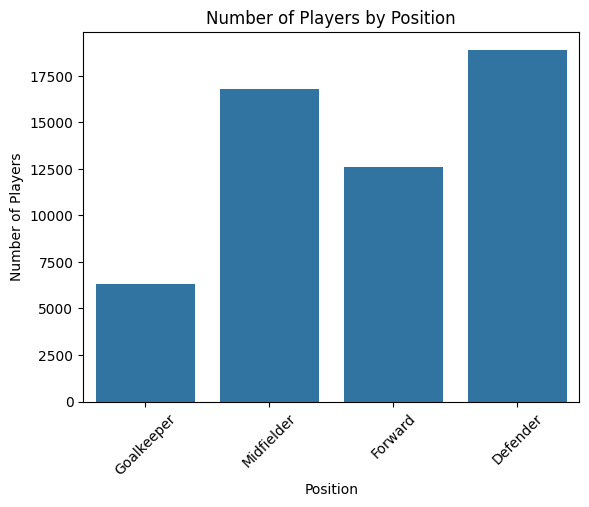

In [ ]:
# 1. Players per position

sns.countplot(
    data=df,
    x="position"
)

plt.xticks(rotation=45)
plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.show()

17. Average Market Value by Position

In [ ]:
# 2. Average market value by position

avg_market_value = (
    df.groupby("position")["market_val_"]
    .mean()
    .sort_values(ascending=False)
)

avg_market_value

,market_val_
position,
Forward,27.243386
Midfielder,22.972888
Defender,15.380288
Goalkeeper,12.176580


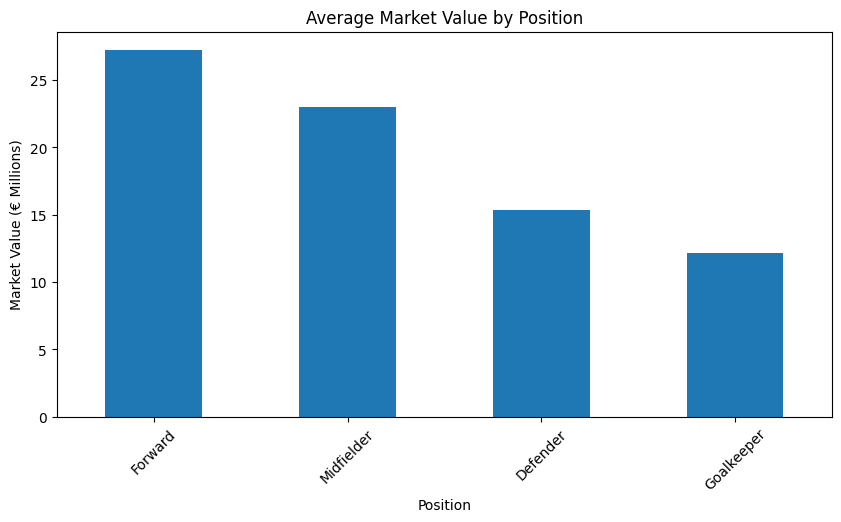

In [ ]:
avg_market_value.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Market Value by Position")
plt.xlabel("Position")
plt.ylabel("Market Value (€ Millions)")
plt.xticks(rotation=45)
plt.show()

18. Top 5 Most Valuable Players

In [ ]:
# 3. Top 5 most valuable players

top_5_players = (
    df[
        ["player_name", "club_name", "market_val_"]
    ]
    .sort_values(
        "market_val_",
        ascending=False
    )
    .head(5)
)

display(top_5_players)

,player_name,club_name,market_val_
38596,Romelu Onana,Brondby,200.0
22096,Romelu Onana,Brondby,200.0
7598,Saleh Al-Qahtani,Kawasaki Frontale,200.0
31377,Romelu Onana,Brondby,200.0
38500,Romelu Onana,Brondby,200.0


19. Age Distribution

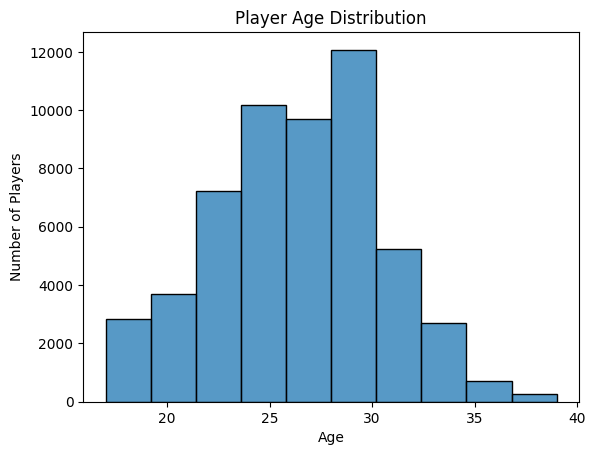

In [ ]:
# 4. Age distribution

sns.histplot(
    data=df,
    x="age",
    bins=10
)

plt.title("Player Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

20. Height vs Weight

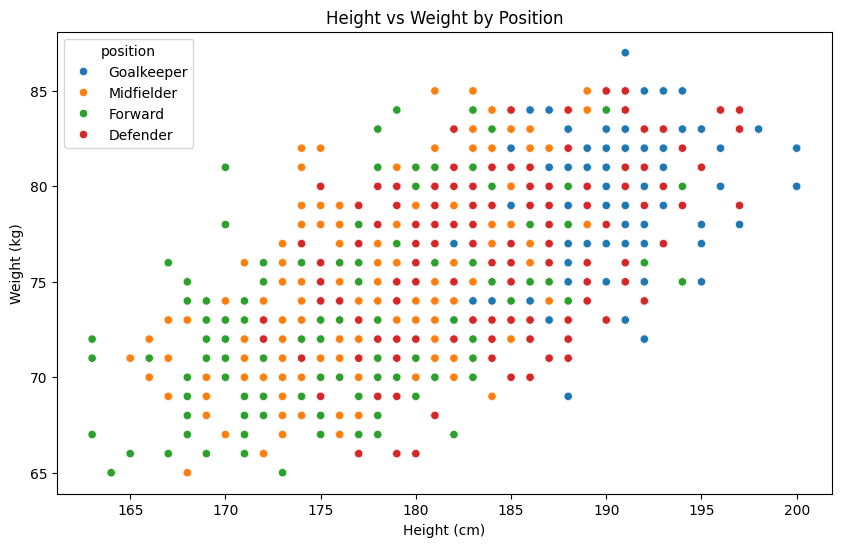

In [ ]:
# 5. Height vs Weight

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="height_cm",
    y="weight_kg",
    hue="position"
)

plt.title("Height vs Weight by Position")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.show()

21. Prepare Machine Learning Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Choose features

features = [
    "age",
    "height_cm",
    "weight_kg",
    "position",
    "preferred_foot",
    "nationality"
]

target = "market_value_eur"

# Create ML dataset

df_ml = df[features + [target]].dropna()

22. Encode Text Columns

In [ ]:
# Encode text columns

le = LabelEncoder()

for col in [
    "position",
    "preferred_foot",
    "nationality"
]:
    df_ml[col] = le.fit_transform(df_ml[col])

23. Separate X and y

In [ ]:
X = df_ml[features]
y = df_ml[target]

24. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (43680, 6)
Testing data: (10920, 6)


25. Scale the Data

In [ ]:
# Scale numerical data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

26. Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model

model.fit(
    X_train_scaled,
    y_train
)

RandomForestRegressor(random_state=42)

27. Make Predictions

In [ ]:
# Make predictions

y_pred = model.predict(X_test_scaled)

28. Evaluate Random Forest Model

In [ ]:
# Evaluate model

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Test MAE:", mae)
print("R2 Score:", r2)

Test MAE: 0.0
R2 Score: 1.0


29. Feature Importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
5,nationality,0.348222
1,height_cm,0.215481
0,age,0.184962
2,weight_kg,0.173364
3,position,0.042069
4,preferred_foot,0.035903


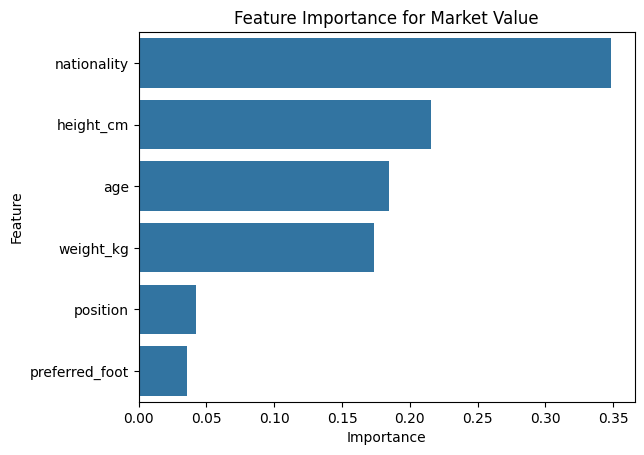

In [ ]:
sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance for Market Value")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

30. Neural Network / Deep Learning Model

In [ ]:
import tensorflow as tf
from tensorflow import keras

31. Build Neural Network

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    keras.layers.Dropout(0.2),

    keras.layers.Dense(
        32,
        activation="relu"
    ),

    keras.layers.Dense(
        16,
        activation="relu"
    ),

    keras.layers.Dense(
        1
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32. Compile the Neural Network

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

33. Train the Neural Network

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1135697264115712.0000 - mae: 20001924.0000 - val_loss: 1147907587702784.0000 - val_mae: 19783882.0000
Epoch 2/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1052384025378816.0000 - mae: 18122082.0000 - val_loss: 978183365066752.0000 - val_mae: 16356744.0000
Epoch 3/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 847008554287104.0000 - mae: 15562224.0000 - val_loss: 789885757685760.0000 - val_mae: 15779630.0000
Epoch 4/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 746308147085312.0000 - mae: 16368520.0000 - val_loss: 755100213575680.0000 - val_mae: 16954510.0000
Epoch 5/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 735569319559168.0000 - mae: 17062648.0000 - val_loss: 750586874036224.0000 - val_mae: 17282612.0000
Epoch 6/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 732181999648768.0000 - mae: 17235102.0000 - val_loss: 748317453582336.0000 - val_mae: 17340970.0000
Epoch 7/50
1092/1092 ━━━━

34. Evaluate Neural Network

In [ ]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test
)

print("Test MAE:", test_mae)

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 714515389874176.0000 - mae: 17434444.0000
Test MAE: 17434444.0


35. Plot Training MAE

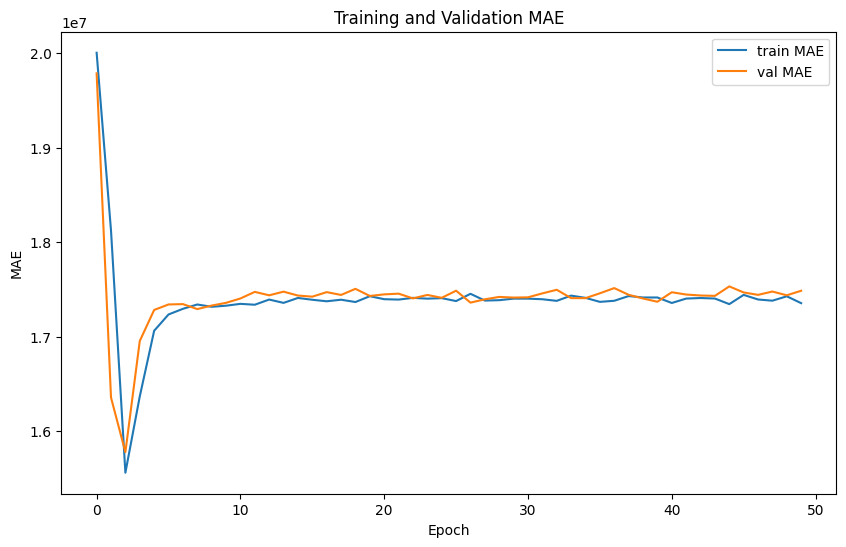

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["mae"],
    label="train MAE"
)

plt.plot(
    history.history["val_mae"],
    label="val MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")

plt.legend()
plt.show()

36. Compare Actual vs Predicted Values

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


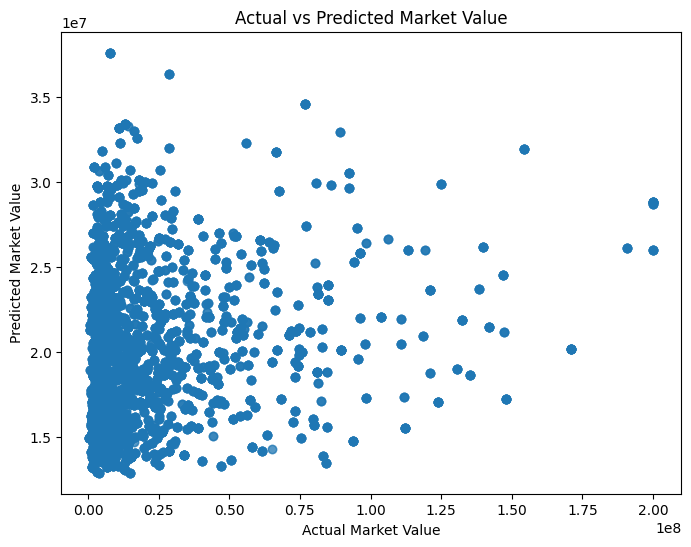

In [ ]:
# Predict test data

nn_predictions = model.predict(
    X_test_scaled
).flatten()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    nn_predictions,
    alpha=0.5
)

plt.xlabel("Actual Market Value")
plt.ylabel("Predicted Market Value")
plt.title("Actual vs Predicted Market Value")

plt.show()

37. Compare Random Forest and Neural Network

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    y_pred
)

nn_mae = mean_absolute_error(
    y_test,
    nn_predictions
)

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Neural Network"
    ],
    "MAE": [
        rf_mae,
        nn_mae
    ]
})

display(comparison)

,Model,MAE
0,Random Forest,0.0
1,Neural Network,17434440.0
